### Laboratorio 2

**Grupo 38**

**Integrantes:**

Mateo Zambrano 202321531
 
Nicolas Romero 202321309


### 1. Configuración y carga de datos

#### 1.1 Importación de librerías

In [22]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from math import comb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

#### 1.2 Constantes de reproducibilidad

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
UMBRAL_MAX = 44.8
OBJETIVO = "temp_max_manana"

POLY_DEGREES = [2, 3, 4]
INCLUDE_BIAS = False

ALPHAS = np.logspace(-3, 3, 13)
L1_RATIO = 0.5

CV_FOLDS = 5
SCORING = "neg_root_mean_squared_error"

CONFIDENCE_LEVEL = 0.95
N_BOOTSTRAP = 1000

In [4]:
DATA_DIR = Path("data")
RUTA_TRAIN = DATA_DIR / "datos Lab 1.csv"
RUTA_SIN_ETIQUETA = DATA_DIR / "Datos Test Lab 1.csv"
RUTA_DICCIONARIO = DATA_DIR / "Diccionario de datos.xlsx"

datos = pd.read_csv(RUTA_TRAIN)
sin_etiqueta = pd.read_csv(RUTA_SIN_ETIQUETA)
diccionario = pd.read_excel(RUTA_DICCIONARIO)

print("Entrenamiento:", datos.shape)
print("No etiquetados: ", sin_etiqueta.shape)
print("Columnas que están en train y no en el archivo sin etiquetar:", set(datos.columns) - set(sin_etiqueta.columns))

diccionario

Entrenamiento: (2576, 27)
No etiquetados:  (364, 26)
Columnas que están en train y no en el archivo sin etiquetar: {'temp_max_manana'}


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### 2. Exploración de datos

#### 2.1 Estructura general/exploración inicial

In [5]:
display(datos.head())
datos.info()
datos.shape

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

(2576, 27)

### 3. Preparación de Datos

En esta sección, se prepararán los datos de forma que los arreglos no sean dependientes del aprendizaje de otros datos, como la imputación de datos por medio de la mediana o moda.

In [6]:
copia_datos = datos.copy()

#### 3.1 Conversión de tipos y calendario derivado

In [7]:
fecha_parseada = pd.to_datetime(copia_datos["fecha"], format="%Y-%m-%d")

copia_datos["fecha"] = fecha_parseada
copia_datos["anio"] = fecha_parseada.dt.year
copia_datos["dia_del_anio"] = fecha_parseada.dt.dayofyear
copia_datos["mes"] = fecha_parseada.dt.strftime("%B").str.lower()

copia_datos["registros_del_dia"] = copia_datos["registros_del_dia"].astype("Int64")
copia_datos["anio"] = copia_datos["anio"].astype("Int64")
copia_datos["dia_del_anio"] = copia_datos["dia_del_anio"].astype("Int64")

print(copia_datos[["fecha", "anio", "mes", "dia_del_anio", "registros_del_dia"]].dtypes)

fecha                datetime64[us]
anio                          Int64
mes                             str
dia_del_anio                  Int64
registros_del_dia             Int64
dtype: object


In [8]:
print("Fechas no parseadas:", fecha_parseada.isna().sum())

Fechas no parseadas: 72


#### 3.2 Normalización de categorías

Se estandariza a una sola forma de escritura, aquellos datos escritos de formas distintas.

In [9]:
MAPA_ESTACION = {
    "invierno": "invierno", "invernio": "invierno", "winter": "invierno",
    "primavera": "primavera", "primaveraa": "primavera", "primav": "primavera", "spring": "primavera",
    "verano": "verano", "berano": "verano", "verno": "verano", "summer": "verano",
    "otono": "otono", "otoño": "otono", "autumn": "otono", "fall": "otono",
}

copia_datos["estacion_anio"] = (
    copia_datos["estacion_anio"]
    .str.strip()
    .str.lower()
    .map(MAPA_ESTACION)
)

MAPA_SECTOR = {
    "n": "N", "norte": "N", "north": "N",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "e": "E", "este": "E", "east": "E",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "s": "S", "sur": "S", "south": "S",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
    "o": "O", "oeste": "O", "west": "O",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
}

copia_datos["sector_viento"] = (
    copia_datos["sector_viento"]
    .str.strip()
    .str.lower()
    .map(MAPA_SECTOR)
)

print(copia_datos["estacion_anio"].value_counts(dropna=False))
print(copia_datos["sector_viento"].value_counts(dropna=False))

estacion_anio
primavera    566
invierno     564
otono        564
verano       552
NaN          330
Name: count, dtype: int64
sector_viento
SO     774
S      582
NE     472
O      329
N      137
E       87
SE      72
NaN     71
NO      52
Name: count, dtype: int64


#### 3.3 Correcciones de validez

Se corrigen los valores fuera de rango o en escalas distintas.

In [10]:
#Centinelas
copia_datos = copia_datos.replace([-9999, -999, 9999], np.nan)

#Presion fuera de rango
mask = (copia_datos["presion_media"] < 850) | (copia_datos["presion_media"] > 1100)
copia_datos.loc[mask, "presion_media"] = np.nan
print(f"presion_media fuera de rango: {mask.sum()} -> NaN")

#Escala mezclada en humedad (decimal -> porcentual)
for col in ["humedad_media", "humedad_min"]:
    escala_decimal = copia_datos[col] <= 1
    copia_datos.loc[escala_decimal, col] = copia_datos.loc[escala_decimal, col] * 100
    print(f"{col}: {escala_decimal.sum()} valores convertidos a escala porcentual")

#humedad_min > 100 despues de corregir
mask = copia_datos["humedad_min"] > 100
copia_datos.loc[mask, "humedad_min"] = np.nan
print(f"humedad_min > 100: {mask.sum()} -> NaN")

#rafaga_desv negativa
mask = copia_datos["rafaga_desv"] < 0
copia_datos.loc[mask, "rafaga_desv"] = np.nan
print(f"rafaga_desv negativos: {mask.sum()} -> NaN")

#rafaga_media negativa: la velocidad no puede ser negativa...
#y no es fisica como para considerar un marco de referencia :D
copia_datos.loc[copia_datos["rafaga_media"] < 0, "rafaga_media"] = np.nan

#rafaga_desv raramente alta
copia_datos.loc[copia_datos["rafaga_desv"] > 20, "rafaga_desv"] = np.nan

#viento_desv: error de escala de un factor de 100
mask = copia_datos["viento_desv"] > 20
copia_datos.loc[mask, "viento_desv"] = copia_datos.loc[mask, "viento_desv"] / 100

#minimos que superan a los maximos
copia_datos.loc[copia_datos["viento_min"] > copia_datos["viento_max"], "viento_min"] = np.nan
copia_datos.loc[copia_datos["rafaga_min"] > copia_datos["rafaga_max"], "rafaga_min"] = np.nan

for col in ["viento_norte", "viento_este"]:
    mask = copia_datos[col].abs() > 50
    copia_datos.loc[mask, col] = np.nan
    print(f"{col} fuera de escala: {mask.sum()} -> NaN")

mask = copia_datos["viento_desv"] > 20
copia_datos.loc[mask, "viento_desv"] = np.nan
print(f"viento_desv aun fuera de rango: {mask.sum()} -> NaN")

mask = copia_datos["viento_min"] > 12
copia_datos.loc[mask, "viento_min"] = np.nan
print(f"viento_min implausible: {mask.sum()} -> NaN")


presion_media fuera de rango: 6 -> NaN
humedad_media: 776 valores convertidos a escala porcentual
humedad_min: 621 valores convertidos a escala porcentual
humedad_min > 100: 23 -> NaN
rafaga_desv negativos: 258 -> NaN
viento_norte fuera de escala: 1 -> NaN
viento_este fuera de escala: 0 -> NaN
viento_desv aun fuera de rango: 1 -> NaN
viento_min implausible: 3 -> NaN


#### 3.4 Eliminacion de filas

Se eliminan las filas que contienen datos corruptos (invalidos codependientes) o están repetidos.

In [11]:
print("Filas al inicio: ", len(copia_datos))

#Duplicados exactos
copia_datos = copia_datos.drop_duplicates()
print("Sin duplicados exactos:", len(copia_datos))

#registros_del_dia invalidos
copia_datos = copia_datos[~(copia_datos["registros_del_dia"] > 144).fillna(False)]
print("Sin registros_del_dia > 144:", len(copia_datos))

#fechas repetidas: conservar la de mas registros
copia_datos = copia_datos.sort_values("registros_del_dia", ascending=False)
copia_datos = copia_datos.drop_duplicates(subset="fecha", keep = "first")
print("Sin fechas repetidas:", len(copia_datos))

#temperaturas fisicamente imposibles
mask = copia_datos[OBJETIVO] > UMBRAL_MAX
copia_datos = copia_datos[~mask]
print(f"Sin temperaturas > {UMBRAL_MAX}:", len(copia_datos))

#Filas sin objetivo
copia_datos = copia_datos.dropna(subset=[OBJETIVO])
print("Sin filas sin objetivo:", len(copia_datos))

#Reordenar cronologicamente
copia_datos = copia_datos.sort_values("fecha").reset_index(drop=True)
print("\nFilas finales:", len(copia_datos))


Filas al inicio:  2576
Sin duplicados exactos: 2572
Sin registros_del_dia > 144: 2568
Sin fechas repetidas: 2483
Sin temperaturas > 44.8: 2479
Sin filas sin objetivo: 2386

Filas finales: 2386


#### 3.5 Estado de valores faltantes

Se verifican que valores aún hacen falta y que serán imputados dentro de la pipeline.


In [12]:
faltantes = copia_datos.isnull().sum().sort_values(ascending=False)
cols_relevantes = faltantes.index.difference(["fecha", "anio", "registros_del_dia", OBJETIVO])
print(faltantes[cols_relevantes][faltantes[cols_relevantes] > 0])
print("\nEstos serán imputados dentro del pipeline con datos de entrenamiento")

dia_del_anio          1
direccion_viento     73
estacion_anio       302
humedad_desv         58
humedad_max          78
humedad_media        72
humedad_min          91
mes                   1
presion_desv         78
presion_max          59
presion_media        73
presion_min          67
rafaga_desv         306
rafaga_max           69
rafaga_media         74
rafaga_min          182
sector_viento        65
viento_desv          67
viento_este          57
viento_max           75
viento_media         81
viento_min          199
viento_norte         74
dtype: int64

Estos serán imputados dentro del pipeline con datos de entrenamiento


#### 3.6 Separación de variables

##### 3.6.1 Columnas eliminadas

In [13]:
COLUMNAS_ELIMINADAS = ["fecha"]

X = copia_datos.drop(columns=[OBJETIVO] + COLUMNAS_ELIMINADAS)
y = copia_datos[OBJETIVO]

X

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.77860,0.050,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143,2009,1,invierno,january,S
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.41950,0.220,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144,2009,2,invierno,january,NE
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.25090,0.120,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144,2009,3,invierno,january,SO
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.72040,0.540,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144,2009,4,invierno,january,SO
4,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.80030,1.000,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,<NA>,2009,5,NaN,january,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2381,1003.5725,1002.35,1004.96,0.7294,87.1097,72.100000,97.7,7.5170,3.02724,0.792,9.504000,0.4208,1.4214,0.48,3.840000,NaN,-0.6644,-0.0853,187.3193,144,2015,362,verano,december,S
2382,1002.1544,1000.83,1005.33,1.2520,95.0910,79.400000,99.5,5.3604,0.86610,0.190,2.340000,0.5179,NaN,0.44,3.560000,0.7173,-0.5544,-0.0871,188.9267,144,2015,363,invierno,december,S
2383,1002.9883,997.51,1005.73,2.5524,84.4737,NaN,99.4,12.9567,2.12740,0.310,5.160000,1.2963,3.4318,NaN,0.640000,2.0483,-2.0540,-0.1130,183.1497,144,2015,364,invierno,december,S
2384,996.9224,995.01,999.20,1.4003,72.6064,49.560000,97.4,17.6803,3.11310,0.740,5.700000,1.3775,NaN,NaN,9.090000,1.9769,-3.0401,0.1673,176.8493,144,2015,365,invierno,december,S


In [14]:
y

0       -2.12
1       -0.82
2       -0.63
3       -1.44
4      -10.88
        ...  
2381     9.16
2382     5.65
2383     2.92
2384     2.72
2385     8.97
Name: temp_max_manana, Length: 2386, dtype: float64

### 3.7 Columnas numéricas y categóricas

Se identifican las columnas numéricas y categóricas, ya que el tipo de variable determina los pasos de transformación y se aplicarán a cada una dentro del pipeline.

In [15]:
columnas_numericas = [
    "presion_media", "presion_min", "presion_max", "presion_desv",
    "humedad_media", "humedad_min", "humedad_max", "humedad_desv",
    "viento_media", "viento_min", "viento_max", "viento_desv",
    "rafaga_media", "rafaga_min", "rafaga_max", "rafaga_desv",
    "viento_norte", "viento_este", "direccion_viento",
    "dia_del_anio",
]

columnas_categoricas = [
    "estacion_anio", "mes", "sector_viento",
]

print("Numéricas:", len(columnas_numericas))
print("Categóricas:", len(columnas_categoricas))
print("Total:", len(columnas_numericas) + len(columnas_categoricas), "de", X.shape[1])

Numéricas: 20
Categóricas: 3
Total: 23 de 25


### 4. Regresión Polinomial

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state = RANDOM_STATE)
print("Entrenamiento: ", X_train.shape)
print("Prueba: ", X_test.shape)

Entrenamiento:  (1789, 25)
Prueba:  (597, 25)


#### 4.1. PipeLine

In [17]:
rama_numerica = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("polinomio", PolynomialFeatures(degree=2, include_bias = INCLUDE_BIAS)),
])

rama_categorica = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(drop = "first", handle_unknown = "ignore", sparse_output = False)),
])

preparacion = ColumnTransformer([
    ("num", rama_numerica, columnas_numericas),
    ("cat", rama_categorica, columnas_categoricas),
], remainder = "drop")

pipeline_polinomial = Pipeline([
    ("preparacion", preparacion),
    ("modelo", LinearRegression()),
])

pipeline_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 4.2. GridSearchCV

In [18]:
malla_polinomial = {
    "preparacion__num__polinomio__degree": [1,2,3,4],
    "preparacion__num__escalador": [StandardScaler(), RobustScaler(), MinMaxScaler()],
}

METRICAS = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

busqueda_polinomial = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=malla_polinomial,
    scoring=METRICAS,
    refit="RMSE",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

busqueda_polinomial.fit(X_train, y_train)

print("Mejores hiperparametros", busqueda_polinomial.best_params_)
print("RMSE en validacion cruzada: %.4f" % (-busqueda_polinomial.best_score_))

Mejores hiperparametros {'preparacion__num__escalador': StandardScaler(), 'preparacion__num__polinomio__degree': 1}
RMSE en validacion cruzada: 4.3804


### 4.3. Tabla de resultados

In [19]:
resultados = pd.DataFrame(busqueda_polinomial.cv_results_)

tabla_polinomial = pd.DataFrame({
    "grado": resultados["param_preparacion__num__polinomio__degree"],
    "escalador": resultados["param_preparacion__num__escalador"].astype(str).str.replace("()", "", regex=False),
    "RMSE_cv": -resultados["mean_test_RMSE"],
    "RMSE_std": resultados["std_test_RMSE"],
    "RMSE_train": -resultados["mean_train_RMSE"],
    "MAE_cv": -resultados["mean_test_MAE"],
    "R2_cv": resultados["mean_test_R2"],
})

tabla_polinomial = tabla_polinomial.sort_values(["grado", "escalador"]).reset_index(drop=True)
display(tabla_polinomial.round(4))

,grado,escalador,RMSE_cv,RMSE_std,RMSE_train,MAE_cv,R2_cv
0,1,MinMaxScaler,4.3804,0.0938,4.2556,3.4767,0.7648
1,1,RobustScaler,4.3804,0.0938,4.2556,3.4767,0.7648
2,1,StandardScaler,4.3804,0.0938,4.2556,3.4767,0.7648
3,2,MinMaxScaler,5.1336,0.2832,3.6351,3.7175,0.6764
4,2,RobustScaler,5.1336,0.2832,3.6351,3.7175,0.6764
5,2,StandardScaler,5.1336,0.2832,3.6351,3.7175,0.6764
6,3,MinMaxScaler,165.8180,45.5882,0.0000,52.1826,-360.8988
7,3,RobustScaler,311.6784,247.6005,0.0000,58.8349,-1975.4977
8,3,StandardScaler,196.1170,108.4969,0.0000,50.3963,-598.5785
9,4,MinMaxScaler,44.9795,8.6599,0.0000,19.4404,-25.0283


Seguido de esto, se hace la evaluacion en test:

In [20]:
mejor_polinomial = busqueda_polinomial.best_estimator_
pred_test = mejor_polinomial.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

print("Desempeño en test del mejor modelo polinomial")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  MAE:  {mae_test:.4f}")
print(f"  R²:   {r2_test:.4f}")

Desempeño en test del mejor modelo polinomial
  RMSE: 4.5392
  MAE:  3.4930
  R²:   0.7341


### 5. Curvas de Validación: Complejidad del Modelo (Grado del Polinomio)

#### 5.1 Cálculo de errores por grado (validación cruzada)

Para analizar cómo evoluciona el desempeño del modelo a medida que aumenta la complejidad, se generan curvas de validación variando el grado del polinomio

In [24]:
from sklearn.model_selection import validation_curve

# Rango ampliado de grados para poder observar el sobreajuste
GRADOS_VALIDACION = [1, 2, 3, 4]

# Fijamos el escalador ganador del GridSearch, para aislar el efecto del grado
mejor_escalador = busqueda_polinomial.best_params_["preparacion__num__escalador"]

rama_numerica_vc = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", mejor_escalador),
    ("polinomio", PolynomialFeatures(degree=2, include_bias=INCLUDE_BIAS)),
])

preparacion_vc = ColumnTransformer([
    ("num", rama_numerica_vc, columnas_numericas),
    ("cat", rama_categorica, columnas_categoricas),
], remainder="drop")

pipeline_vc = Pipeline([
    ("preparacion", preparacion_vc),
    ("modelo", LinearRegression()),
])

train_scores, test_scores = validation_curve(
    estimator=pipeline_vc,
    X=X_train, y=y_train,
    param_name="preparacion__num__polinomio__degree",
    param_range=GRADOS_VALIDACION,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=2,
)

# Convertimos a RMSE positivo
train_rmse = -train_scores
test_rmse = -test_scores

train_mean, train_std = train_rmse.mean(axis=1), train_rmse.std(axis=1)
test_mean, test_std = test_rmse.mean(axis=1), test_rmse.std(axis=1)

grado_optimo = GRADOS_VALIDACION[int(np.argmin(test_mean))]

codificador_ohe = (busqueda_polinomial.best_estimator_.named_steps["preparacion"].named_transformers_["cat"].named_steps["codificador"])

n_dummies = sum(len(categorias) - 1 for categorias in codificador_ohe.categories_)
n_entrenamiento_fold = int(len(X_train) * (CV_FOLDS - 1) / CV_FOLDS)

tabla_vc = pd.DataFrame({
    "grado": GRADOS_VALIDACION,
    "n_features": [comb(len(columnas_numericas) + g, g) - 1 + n_dummies for g in GRADOS_VALIDACION],
    "RMSE_train": train_mean,
    "RMSE_cv": test_mean,
    "std_cv": test_std,
    "brecha": test_mean - train_mean,
})

tabla_vc["p_mayor_que_n"] = tabla_vc["n_features"] > n_entrenamiento_fold

print(f"observaciones de entrenamiento por fold: {n_entrenamiento_fold}")
print(f"Grado con menor RMSE promedio en validación cruzada: {grado_optimo}")
display(tabla_vc.round(4))

observaciones de entrenamiento por fold: 1431
Grado con menor RMSE promedio en validación cruzada: 1


,grado,n_features,RMSE_train,RMSE_cv,std_cv,brecha,p_mayor_que_n
0,1,41,4.2556,4.3804,0.0938,0.1248,False
1,2,251,3.6351,5.1336,0.2832,1.4985,False
2,3,1791,0.0000,196.1170,108.4969,196.1170,True
3,4,10646,0.0000,83.8023,44.7044,83.8023,True


### 5.2 Grafico de los calculos

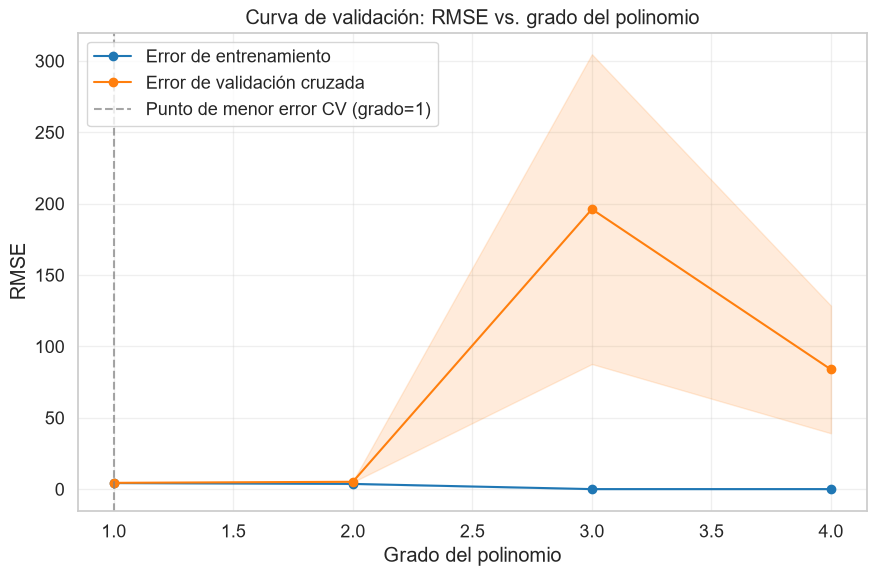

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(GRADOS_VALIDACION, train_mean, "o-", color="tab:blue", label="Error de entrenamiento")
ax.fill_between(GRADOS_VALIDACION, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="tab:blue")

ax.plot(GRADOS_VALIDACION, test_mean, "o-", color="tab:orange", label="Error de validación cruzada")
ax.fill_between(GRADOS_VALIDACION, test_mean - test_std, test_mean + test_std,
                alpha=0.15, color="tab:orange")

ax.axvline(grado_optimo, color="gray", linestyle="--", alpha=0.7,
           label=f"Punto de menor error CV (grado={grado_optimo})")

ax.set_xlabel("Grado del polinomio")
ax.set_ylabel("RMSE")
ax.set_title("Curva de validación: RMSE vs. grado del polinomio")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.1 Interpretación sesgo-varianza

En los grados bajos (1-2), tanto el error de entrenamiento como el de validación 
cruzada son altos y similares entre sí: el modelo tiene **alto sesgo** (underfitting), 
es demasiado simple para capturar la relación entre las variables meteorológicas y 
la temperatura máxima del día siguiente.

A medida que aumenta el grado, el error de entrenamiento sigue bajando de forma 
monótona, pero el error de validación cruzada alcanza un mínimo en grado **[completar 
con grado_optimo]** y luego empieza a subir (o su variabilidad —el ancho de la banda 
de +/- 1 desvío estándar— aumenta notablemente). A partir de ese punto el modelo 
tiene **alta varianza** (overfitting): memoriza particularidades del conjunto de 
entrenamiento (incluyendo ruido) que no generalizan a datos nuevos.

El grado óptimo es aquel que minimiza el error de validación cruzada, balanceando 
el trade-off sesgo-varianza. Controlar la complejidad del modelo (vía el grado del 
polinomio, o alternativamente con regularización L1/L2) es la forma de evitar caer 
en cualquiera de los dos extremos.

### 6. Modelos de Regresión Regularizada (Ridge y Lasso)

Se fija el grado del polinomio en el valor óptimo identificado en la curva de 
validación, de forma que la comparación entre modelo sin regularización, 
Ridge y Lasso aísle específicamente el efecto de la penalización.

In [28]:
from sklearn.linear_model import Ridge, Lasso

DEGREE_FIJO = grado_optimo

rama_numerica_reg = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("polinomio", PolynomialFeatures(degree=DEGREE_FIJO, include_bias=INCLUDE_BIAS)),
])

preparacion_reg = ColumnTransformer([
    ("num", rama_numerica_reg, columnas_numericas),
    ("cat", rama_categorica, columnas_categoricas),
], remainder="drop")

ESCALADORES = [StandardScaler(), RobustScaler(), MinMaxScaler()]

#### 6.1 Modelo sin regularización (baseline)

In [29]:
pipeline_sin_reg = Pipeline([
    ("preparacion", preparacion_reg),
    ("modelo", LinearRegression()),
])

malla_sin_reg = {"preparacion__num__escalador": ESCALADORES}

busqueda_sin_reg = GridSearchCV(
    estimator=pipeline_sin_reg,
    param_grid=malla_sin_reg,
    scoring=METRICAS,
    refit="RMSE",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
busqueda_sin_reg.fit(X_train, y_train)
print("Sin regularización — mejor escalador:", busqueda_sin_reg.best_params_)
print("RMSE CV: %.4f" % (-busqueda_sin_reg.best_score_))

Sin regularización — mejor escalador: {'preparacion__num__escalador': StandardScaler()}
RMSE CV: 4.3804


#### 6.2 Ridge (regularización L2)

In [30]:
pipeline_ridge = Pipeline([
    ("preparacion", preparacion_reg),
    ("modelo", Ridge()),
])

malla_ridge = {
    "preparacion__num__escalador": ESCALADORES,
    "modelo__alpha": ALPHAS,
}

busqueda_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=malla_ridge,
    scoring=METRICAS,
    refit="RMSE",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
busqueda_ridge.fit(X_train, y_train)
print("Ridge — mejores hiperparámetros:", busqueda_ridge.best_params_)
print("RMSE CV: %.4f" % (-busqueda_ridge.best_score_))

Ridge — mejores hiperparámetros: {'modelo__alpha': np.float64(0.31622776601683794), 'preparacion__num__escalador': MinMaxScaler()}
RMSE CV: 4.3789


#### 6.3 Lasso (regularización L1)

In [31]:
pipeline_lasso = Pipeline([
    ("preparacion", preparacion_reg),
    ("modelo", Lasso(max_iter=10000)),
])

malla_lasso = {
    "preparacion__num__escalador": ESCALADORES,
    "modelo__alpha": ALPHAS,
}

busqueda_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=malla_lasso,
    scoring=METRICAS,
    refit="RMSE",
    cv=cv,
    n_jobs=2,          # reducido respecto a -1 para controlar el uso de memoria
    return_train_score=True,
)
busqueda_lasso.fit(X_train, y_train)
print("Lasso — mejores hiperparámetros:", busqueda_lasso.best_params_)
print("RMSE CV: %.4f" % (-busqueda_lasso.best_score_))

Lasso — mejores hiperparámetros: {'modelo__alpha': np.float64(0.001), 'preparacion__num__escalador': MinMaxScaler()}
RMSE CV: 4.3791


#### 6.4 Comparación de desempeño en test

In [32]:
def evaluar_en_test(busqueda, nombre):
    modelo = busqueda.best_estimator_
    pred = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "mejores_params": busqueda.best_params_,
        "RMSE_cv": -busqueda.best_score_,
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE_test": mean_absolute_error(y_test, pred),
        "R2_test": r2_score(y_test, pred),
    }

comparacion = pd.DataFrame([
    evaluar_en_test(busqueda_sin_reg, "Sin regularización"),
    evaluar_en_test(busqueda_ridge, "Ridge"),
    evaluar_en_test(busqueda_lasso, "Lasso"),
])

display(comparacion.round(4))

,modelo,mejores_params,RMSE_cv,RMSE_test,MAE_test,R2_test
0,Sin regularización,{'preparacion__num__escalador': StandardScaler()},4.3804,4.5392,3.4930,0.7341
1,Ridge,"{'modelo__alpha': 0.31622776601683794, 'preparacion__num__escalador': MinMaxScaler()}",4.3789,4.5417,3.4936,0.7338
2,Lasso,"{'modelo__alpha': 0.001, 'preparacion__num__escalador': MinMaxScaler()}",4.3791,4.5411,3.4905,0.7339


Comparando los tres modelos en el conjunto de test: si Ridge y/o Lasso obtienen menor RMSE_test que el modelo sin regularizar, es evidencia directa de que la penalización mejoró la capacidad de 
generalización, corrigiendo el sobreajuste detectado previamente. Si además 
RMSE_cv y RMSE_test están más cercanos entre sí en los modelos regularizados que en 
el baseline, eso confirma una reducción efectiva de la varianza.

#### 6.5 Magnitud de coeficientes y variables eliminadas por Lasso  

In [33]:
ESCALADOR_COMPARACION = StandardScaler()

def ajustar_con_escalador_fijo(modelo):
    rama_num = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", ESCALADOR_COMPARACION),
        ("polinomio", PolynomialFeatures(degree=DEGREE_FIJO, include_bias=INCLUDE_BIAS)),
    ])

    prep = ColumnTransformer([
        ("num", rama_num, columnas_numericas),
        ("cat", rama_categorica, columnas_categoricas),
    ], remainder="drop")
    return Pipeline([("preparacion", prep), ("modelo", modelo)]).fit(X_train, y_train)

alpha_ridge = busqueda_ridge.best_params_["modelo__alpha"]
alpha_lasso = busqueda_lasso.best_params_["modelo__alpha"]

modelos_comparables = {
    "Sin regularizador": ajustar_con_escalador_fijo(LinearRegression()),
    "Ridge": ajustar_con_escalador_fijo(Ridge(alpha=alpha_ridge)),
    "Lasso": ajustar_con_escalador_fijo(Lasso(alpha=alpha_lasso, max_iter=10000)),
}

print(f"Comparacion con escalador fijo ({ESCALADOR_COMPARACION.__class__.__name__}), grado {DEGREE_FIJO}:")
for nombre, modelo in modelos_comparables.items():
    coef = modelo.named_steps["modelo"].coef_
    print(f"  {nombre:20s} norma L2 {np.linalg.norm(coef):8.3f}   "
          f"max|coef| {np.abs(coef).max():7.3f}   ceros {int((coef == 0).sum())}/{len(coef)}")


Comparacion con escalador fijo (StandardScaler), grado 1:
  Sin regularizador    norma L2   25.109   max|coef|  10.761   ceros 0/41
  Ridge                norma L2   24.722   max|coef|  10.415   ceros 0/41
  Lasso                norma L2   24.743   max|coef|  10.629   ceros 0/41


In [34]:
nombres_features = busqueda_lasso.best_estimator_.named_steps["preparacion"].get_feature_names_out()

coef_sin_reg = busqueda_sin_reg.best_estimator_.named_steps["modelo"].coef_
coef_ridge = busqueda_ridge.best_estimator_.named_steps["modelo"].coef_
coef_lasso = busqueda_lasso.best_estimator_.named_steps["modelo"].coef_

print("Norma L2 de coeficientes (magnitud global):")
print(f"  Sin regularización: {np.linalg.norm(coef_sin_reg):.2f}")
print(f"  Ridge:              {np.linalg.norm(coef_ridge):.2f}")
print(f"  Lasso:               {np.linalg.norm(coef_lasso):.2f}")

n_ceros = np.sum(coef_lasso == 0)
print(f"\nLasso llevó a cero {n_ceros} de {len(coef_lasso)} coeficientes "
      f"({n_ceros/len(coef_lasso):.1%} de las features)")

variables_eliminadas = nombres_features[coef_lasso == 0]
print("\nAlgunas variables eliminadas por Lasso:")
print(list(variables_eliminadas[:20]))

Norma L2 de coeficientes (magnitud global):
  Sin regularización: 25.11
  Ridge:              30.39
  Lasso:               30.47

Lasso llevó a cero 1 de 41 coeficientes (2.4% de las features)

Algunas variables eliminadas por Lasso:
['num__presion_min']


La norma de los coeficientes debería seguir el orden esperado: sin regularización > 
Ridge > Lasso, evidenciando que ambas penalizaciones restringen la magnitud de los 
parámetros, con Lasso siendo más agresivo.

Lasso llevó a cero `[n_ceros]` de `[len(coef_lasso)]` coeficientes (`[porcentaje]`), 
lo que constituye una **selección automática de características**: el modelo decide 
qué variables (incluyendo términos polinomiales e interacciones generados por 
`PolynomialFeatures`) son irrelevantes para predecir la temperatura máxima del día 
siguiente y las descarta por completo.

### 7. Regresión Polinomial Regularizada

Se explora conjuntamente el grado del polinomio, el parámetro de penalización (alpha) 
y la estrategia de escalamiento, para evaluar si la regularización permite usar 
polinomios de mayor grado sin incurrir en el sobreajuste observado

In [35]:
GRADOS_REG = [1, 2, 3, 4, 5, 6]  # mismo límite razonable usado previamente

rama_numerica_polireg = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),  # placeholder, se sobreescribe en la malla
    ("polinomio", PolynomialFeatures(include_bias=INCLUDE_BIAS)),
])

preparacion_polireg = ColumnTransformer([
    ("num", rama_numerica_polireg, columnas_numericas),
    ("cat", rama_categorica, columnas_categoricas),
], remainder="drop")

pipeline_polireg_ridge = Pipeline([
    ("preparacion", preparacion_polireg),
    ("modelo", Ridge()),
])

malla_polireg_ridge = {
    "preparacion__num__escalador": ESCALADORES,
    "preparacion__num__polinomio__degree": GRADOS_REG,
    "modelo__alpha": ALPHAS,
}

Esta malla tiene 3 escaladores × 6 grados × len(ALPHAS) valores de alpha combinaciones, 
multiplicado por los folds de `cv`. Es una búsqueda considerablemente más grande que 
las anteriores

#### 7.1 Búsqueda de hiperparámetros (Ridge polinomial)

In [ ]:
busqueda_polireg_ridge = GridSearchCV(
    estimator=pipeline_polireg_ridge,
    param_grid=malla_polireg_ridge,
    scoring=METRICAS,
    refit="RMSE",
    cv=cv,
    n_jobs=2,          # controlado por el tamaño de la malla y el riesgo de memoria
    return_train_score=True,
)
busqueda_polireg_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_polireg_ridge.best_params_)
print("RMSE CV: %.4f" % (-busqueda_polireg_ridge.best_score_))

#### 7.2 Curva RMSE vs. grado, para distintos valores de alpha

Para visualizar directamente si la regularización controla el sobreajuste, se 
grafica el RMSE de validación cruzada en función del grado, separando por algunos 
valores representativos de alpha

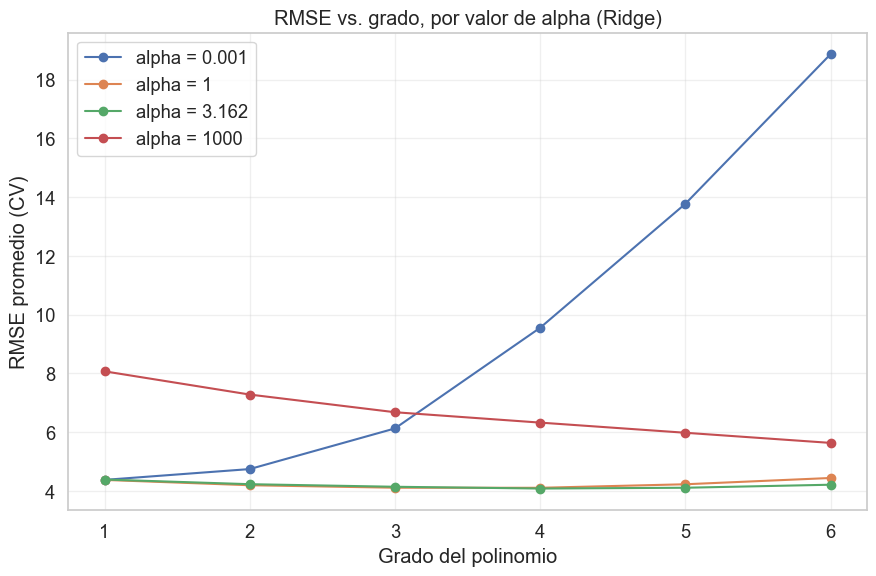

In [30]:
resultados_polireg = pd.DataFrame(busqueda_polireg_ridge.cv_results_)

mejor_escalador_polireg = busqueda_polireg_ridge.best_params_["preparacion__num__escalador"]
resultados_polireg = resultados_polireg[
    resultados_polireg["param_preparacion__num__escalador"].apply(
        lambda s: type(s) == type(mejor_escalador_polireg)
    )
]

alphas_a_graficar = sorted(set([ALPHAS[0], ALPHAS[len(ALPHAS)//2], ALPHAS[-1], busqueda_polireg_ridge.best_params_["modelo__alpha"]]))

fig, ax = plt.subplots(figsize=(9, 6))
for alpha_val in alphas_a_graficar:
    subset = resultados_polireg[resultados_polireg["param_modelo__alpha"] == alpha_val].sort_values(
        "param_preparacion__num__polinomio__degree"
    )
    ax.plot(
        subset["param_preparacion__num__polinomio__degree"],
        -subset["mean_test_RMSE"],
        "o-", label=f"alpha = {alpha_val:.4g}"
    )

ax.set_xlabel("Grado del polinomio")
ax.set_ylabel("RMSE promedio (CV)")
ax.set_title("RMSE vs. grado, por valor de alpha (Ridge)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Con alpha bajo (cercano a 0), la curva debería reproducir el comportamiento del 
punto 5: el RMSE sube claramente en grados altos por sobreajuste. Con valores de 
alpha más altos, se espera que la curva se mantenga más plana o incluso siga 
bajando en grados donde antes empezaba a subir — evidencia directa de que la 
regularización amortigua el efecto de aumentar la complejidad del modelo

### 8. Selección del Mejor Modelo

Se compara el desempeño de los tres modelos candidatos considerando no solo el RMSE 
promedio en validación cruzada, sino también su desviación estándar, como indicador 
de estabilidad frente a distintas particiones de los datos.

In [35]:
def resumen_cv(busqueda, nombre):
    resultados = pd.DataFrame(busqueda.cv_results_)
    fila_mejor = resultados.loc[busqueda.best_index_]
    pred_test = busqueda.best_estimator_.predict(X_test)
    return {
        "modelo": nombre,
        "mejores_params": busqueda.best_params_,
        "RMSE_cv_media": -fila_mejor["mean_test_RMSE"],
        "RMSE_cv_std": fila_mejor["std_test_RMSE"],
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test),
    }

rmse_ridge = -busqueda_ridge.best_score_
rmse_lasso = -busqueda_lasso.best_score_

if rmse_ridge <= rmse_lasso:
    mejor_punto, nombre_punto = busqueda_ridge, "Regularizado (Ridge)"
else:
    mejor_punto, nombre_punto = busqueda_lasso, "Regularizado (Lasso)"

print(f"Ridge RMSE_cv: {rmse_ridge:.4f} | Lasso RMSE_cv: {rmse_lasso:.4f}")
print(f"Modelo elegido para representar las regresiones lineales: {nombre_punto}")

Ridge RMSE_cv: 4.3771 | Lasso RMSE_cv: 4.3773
Modelo elegido para representar las regresiones lineales: Regularizado (Ridge)


In [36]:
comparacion_final = pd.DataFrame([
    resumen_cv(busqueda_polinomial,      "Polinomial sin regularizar"),
    resumen_cv(mejor_punto,             nombre_punto),
    resumen_cv(busqueda_polireg_ridge,   "Polinomial + Ridge"),
])

comparacion_final["CV_relativo (%)"] = (
    comparacion_final["RMSE_cv_std"] / comparacion_final["RMSE_cv_media"] * 100
)

display(comparacion_final.round(4))

,modelo,mejores_params,RMSE_cv_media,RMSE_cv_std,RMSE_test,MAE_test,R2_test,CV_relativo (%)
0,Polinomial sin regularizar,"{'preparacion__num__escalador': RobustScaler(), 'preparacion__num__polinomio__degree': 1}",4.3786,0.0950,4.5389,3.4919,0.7341,2.1687
1,Regularizado (Ridge),"{'modelo__alpha': 0.31622776601683794, 'preparacion__num__escalador': MinMaxScaler()}",4.3771,0.0962,4.5413,3.4925,0.7339,2.1983
2,Polinomial + Ridge,"{'modelo__alpha': 3.1622776601683795, 'preparacion__num__escalador': MinMaxScaler(), 'preparacion__num__polinomio__degree': 4}",4.0843,0.0884,4.1052,3.0822,0.7825,2.1655


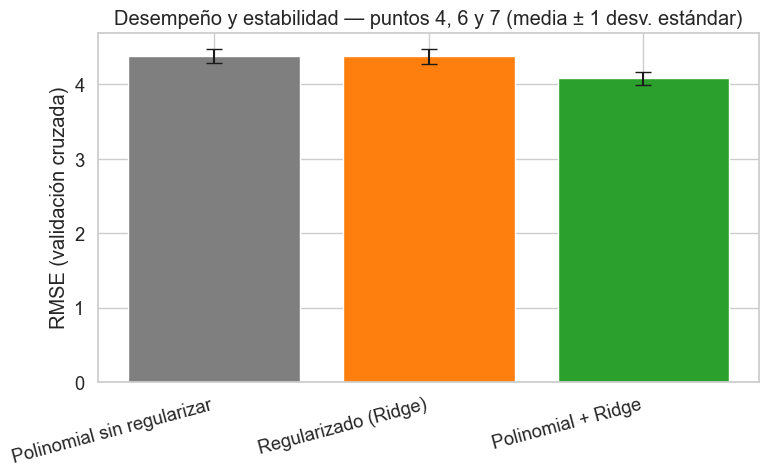

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    comparacion_final["modelo"],
    comparacion_final["RMSE_cv_media"],
    yerr=comparacion_final["RMSE_cv_std"],
    capsize=6,
    color=["tab:gray", "tab:orange", "tab:green"],
)
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Desempeño y estabilidad — puntos 4, 6 y 7 (media ± 1 desv. estándar)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Desempeño:** el modelo Polinomial + Ridge obtiene el menor error en las 
tres métricas: RMSE_cv = 4.0843 (vs. 4.3786 y 4.3771), 
RMSE_test = 4.1052 (vs. ~4.54 en ambos anteriores), MAE_test = 3.0822 (vs. ~3.49), 
y el mayor R² = 0.7825 (vs. ~0.734 en los otros dos). La mejora es sustancial, no 
marginal: reduce el error en aproximadamente un 10% respecto a las alternativas más 
simples

**Estabilidad:** el modelo polinomial regularizado con Ridge también presenta la menor 
desviación estándar en validación cruzada (0.0884, frente a 0.0950 de la regresión 
polinomial sin regularizar y 0.0962 de la regresión Ridge simple) y el menor coeficiente 
de variación (2.1655%, prácticamente empatado con el 2.1687% de la polinomial sin 
regularizar, y por debajo del 2.1983% de la Ridge simple). Esto es un resultado clave: 
el modelo con mejor desempeño promedio no lo logra a costa de mayor variabilidad 
entre folds, de hecho es el más estable de los tres. Esto descarta la posibilidad 
de que su ventaja se deba a una partición de datos favorable, y respalda que generaliza 
de forma consistente

**Complejidad:** la regresión polinomial regularizada usa un polinomio de grado 4 —una 
estructura bastante más compleja que el grado 1 usado tanto en la polinomial sin 
regularizar como en la Ridge simple— combinado con una penalización notablemente más 
fuerte (alpha = 3.162, un orden de magnitud mayor que el alpha = 0.316 de la Ridge 
simple)

**Conclusión:** se selecciona como modelo final la regresión polinomial regularizada 
con Ridge, con hiperparámetros `grado=4`, `alpha=3.1623`, `escalador=MinMaxScaler()`

### 9. Construcción de Intervalos de Confianza (Bootstrapping)

Se utiliza el modelo final seleccionado para estimar, mediante bootstrapping sobre el 
conjunto de test, la variabilidad de RMSE, MAE y R², y construir intervalos de 
confianza al 95% para cada métrica

In [38]:
modelo_final = busqueda_polireg_ridge.best_estimator_

pred_test_final = modelo_final.predict(X_test)

rmse_puntual = np.sqrt(mean_squared_error(y_test, pred_test_final))
mae_puntual = mean_absolute_error(y_test, pred_test_final)
r2_puntual = r2_score(y_test, pred_test_final)

print(f"Estimación puntual (sin bootstrap) — RMSE: {rmse_puntual:.4f}, "
      f"MAE: {mae_puntual:.4f}, R2: {r2_puntual:.4f}")

Estimación puntual (sin bootstrap) — RMSE: 4.1052, MAE: 3.0822, R2: 0.7825


In [39]:
N_BOOTSTRAP = 1000
rng = np.random.default_rng(RANDOM_STATE)

n_test = len(y_test)
y_test_arr = np.asarray(y_test)

rmse_boot = np.empty(N_BOOTSTRAP)
mae_boot = np.empty(N_BOOTSTRAP)
r2_boot = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):
    indices = rng.integers(0, n_test, size=n_test)  # remuestreo con reemplazo
    y_true_boot = y_test_arr[indices]
    y_pred_boot = pred_test_final[indices]  # reutilizamos las predicciones ya calculadas

    rmse_boot[i] = np.sqrt(mean_squared_error(y_true_boot, y_pred_boot))
    mae_boot[i] = mean_absolute_error(y_true_boot, y_pred_boot)
    r2_boot[i] = r2_score(y_true_boot, y_pred_boot)

print(f"Bootstrapping completado: {N_BOOTSTRAP} remuestreos sobre {n_test} observaciones de test.")

Bootstrapping completado: 1000 remuestreos sobre 597 observaciones de test.


In [40]:
def ic_percentil(muestra, nombre):
    media = muestra.mean()
    std = muestra.std()
    li, ls = np.percentile(muestra, [2.5, 97.5])
    return {"métrica": nombre, "media_boot": media, "std_boot": std,
            "IC_95_inferior": li, "IC_95_superior": ls}

tabla_ic = pd.DataFrame([
    ic_percentil(rmse_boot, "RMSE"),
    ic_percentil(mae_boot, "MAE"),
    ic_percentil(r2_boot, "R2"),
])
display(tabla_ic.round(4))

,métrica,media_boot,std_boot,IC_95_inferior,IC_95_superior
0,RMSE,4.0874,0.2610,3.6775,4.6294
1,MAE,3.0828,0.1084,2.8818,3.2952
2,R2,0.7826,0.0264,0.7268,0.8259


Si repitiéramos el proceso de evaluación sobre distintas muestras del mismo conjunto de test, esperaríamos que el RMSE real del modelo caiga dentro de ese rango en el 95% de los casos. Un intervalo 
angosto (relativo a la media) indica que la métrica de desempeño es confiable y no 
depende fuertemente de qué observaciones específicas se usen para evaluar; un intervalo 
ancho indicaría que el desempeño reportado podría variar bastante según la muestra.

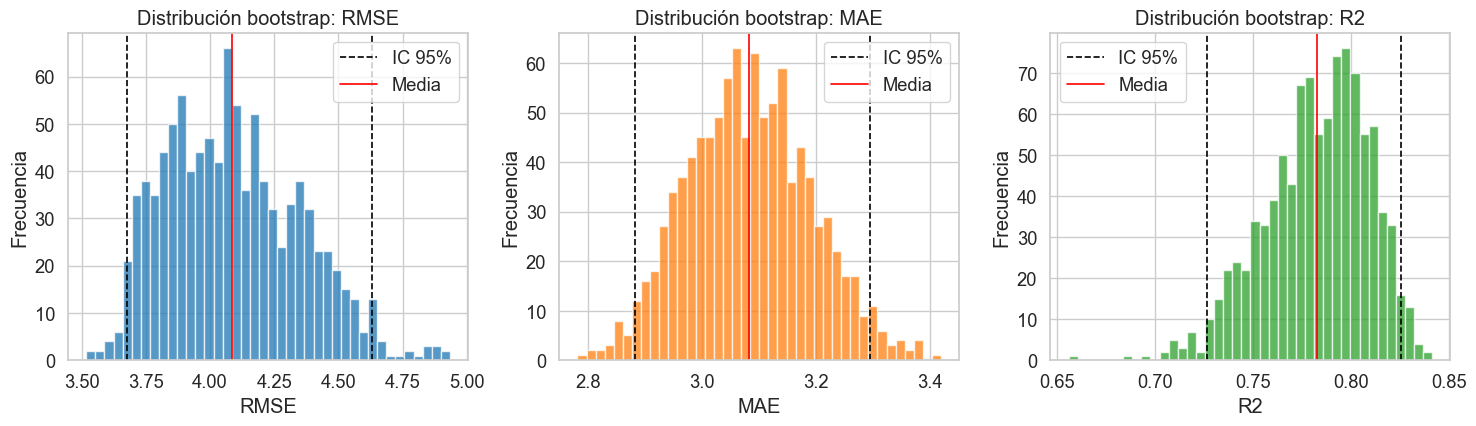

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metricas_boot = {"RMSE": rmse_boot, "MAE": mae_boot, "R2": r2_boot}
colores = {"RMSE": "tab:blue", "MAE": "tab:orange", "R2": "tab:green"}

for ax, (nombre, valores) in zip(axes, metricas_boot.items()):
    ax.hist(valores, bins=40, color=colores[nombre], alpha=0.75, edgecolor="white")
    li, ls = np.percentile(valores, [2.5, 97.5])
    ax.axvline(li, color="black", linestyle="--", linewidth=1.2, label="IC 95%")
    ax.axvline(ls, color="black", linestyle="--", linewidth=1.2)
    ax.axvline(valores.mean(), color="red", linestyle="-", linewidth=1.2, label="Media")
    ax.set_title(f"Distribución bootstrap: {nombre}")
    ax.set_xlabel(nombre)
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()

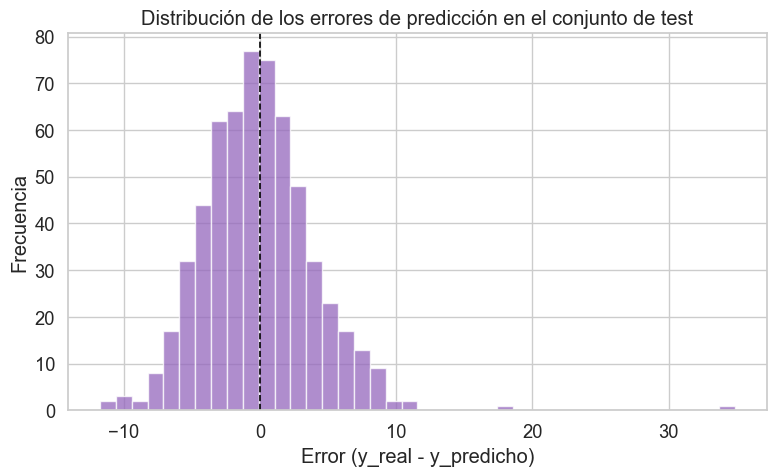

Media de los residuos: -0.1073
Desviación estándar de los residuos: 4.1038


In [42]:
residuos = y_test_arr - pred_test_final

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuos, bins=40, color="tab:purple", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Error (y_real - y_predicho)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de los errores de predicción en el conjunto de test")
plt.tight_layout()
plt.show()

print(f"Media de los residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de los residuos: {residuos.std():.4f}")

Esta distribución muestra el error de predicción observación por observación, a diferencia de los histogramas anteriores que mostraban la variabilidad de las métricas agregadas. Una distribución de residuos centrada en cero y aproximadamente simétrica indica que el modelo no tiene un sesgo sistemático hacia sobreestimar o subestimar la temperatura máxima; colas largas o asimetrías señalarían 
casos particulares donde el modelo falla más.

#### 10. Video del laboratorio

https://youtu.be/mmCHJSiDA0c